In [2]:
print("Suraj")

Suraj


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubh0799/churn-modelling")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-modelling' dataset.
Path to dataset files: /kaggle/input/churn-modelling


In [12]:
import os
print(os.listdir(path))


['Churn_Modelling.csv']


In [14]:
df1 = pd.read_csv('/kaggle/input/churn-modelling/Churn_Modelling.csv')

In [15]:
df1.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df1.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [17]:
df = df1[['Geography', 'Gender', 'Exited']]

In [18]:
df.head(5)

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0


In [19]:
df.Exited.value_counts()

,count
Exited,
0,7963
1,2037


## Univariate Analysis

In [20]:
df.Exited.value_counts(normalize=True)*100

,proportion
Exited,
0,79.63
1,20.37


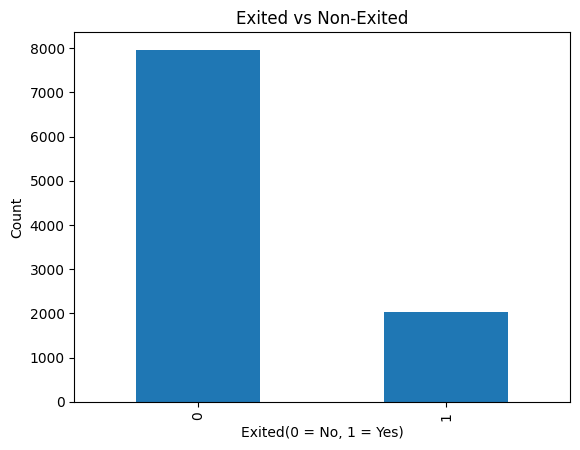

In [21]:
df['Exited'].value_counts().plot(kind='bar')
plt.title("Exited vs Non-Exited")
plt.xlabel("Exited(0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

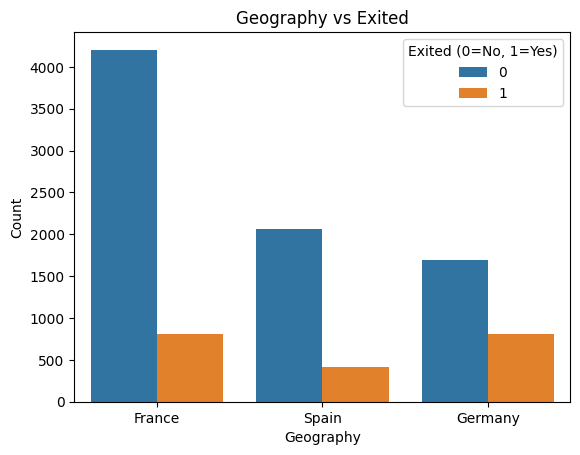

In [37]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Exited")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.legend(title="Exited (0=No, 1=Yes)")
plt.show()


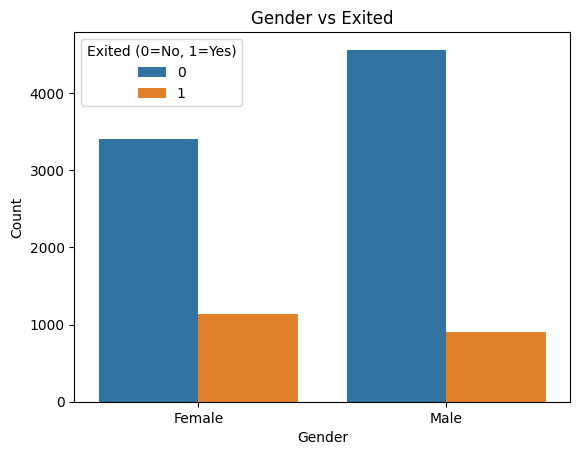

In [23]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender vs Exited")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Exited (0=No, 1=Yes)")
plt.show()

## Bivariate Analysis

<Axes: xlabel='Gender', ylabel='Count'>

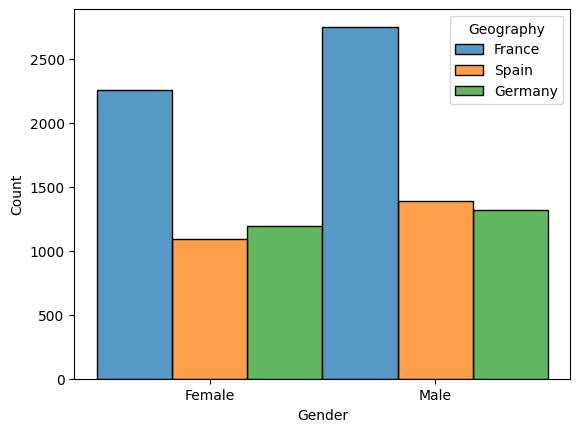

In [38]:
sns.histplot(x = 'Gender', hue='Geography', data = df, multiple="dodge")

In [30]:
df2 = df[df["Exited"] == 1]

<Axes: xlabel='Gender', ylabel='Count'>

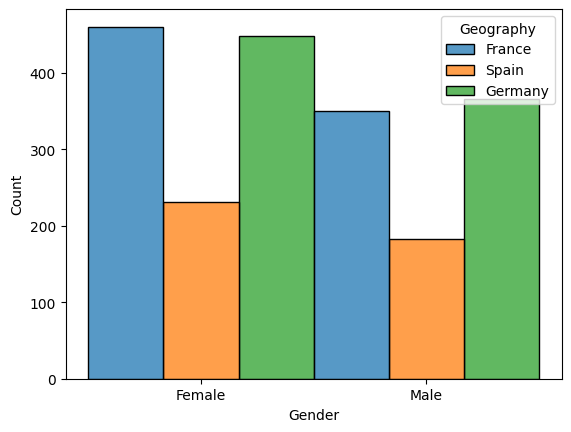

In [46]:
sns.histplot(x='Gender', hue='Geography', data=df2, multiple="dodge")

## Numerical Analysis

+1 --> Positive Correlation

-1 --> Negative Correlation

~0 --> No Correlation

In [49]:
df = df1[['CreditScore', 'Age', 'Tenure', 'Balance',
              'NumOfProducts', 'EstimatedSalary', 'Exited']]

df.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204,-0.047820
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,0.012097,1.000000


<Axes: >

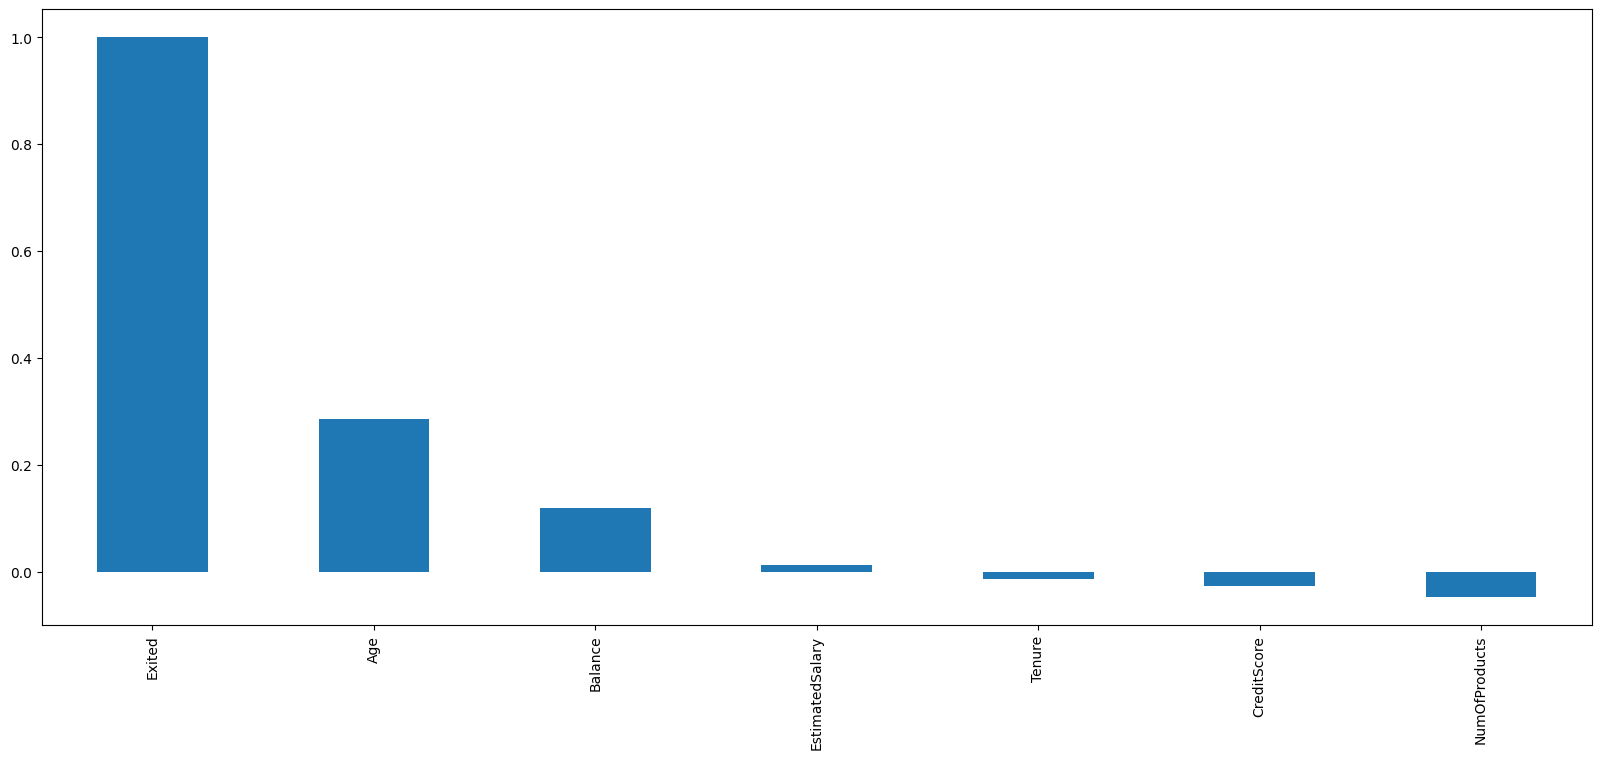

In [50]:
plt.figure(figsize=(20,8))
df.corr()['Exited'].sort_values(ascending=False).plot(kind='bar')

In [51]:
df.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204,-0.047820
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,0.012097,1.000000


<Axes: >

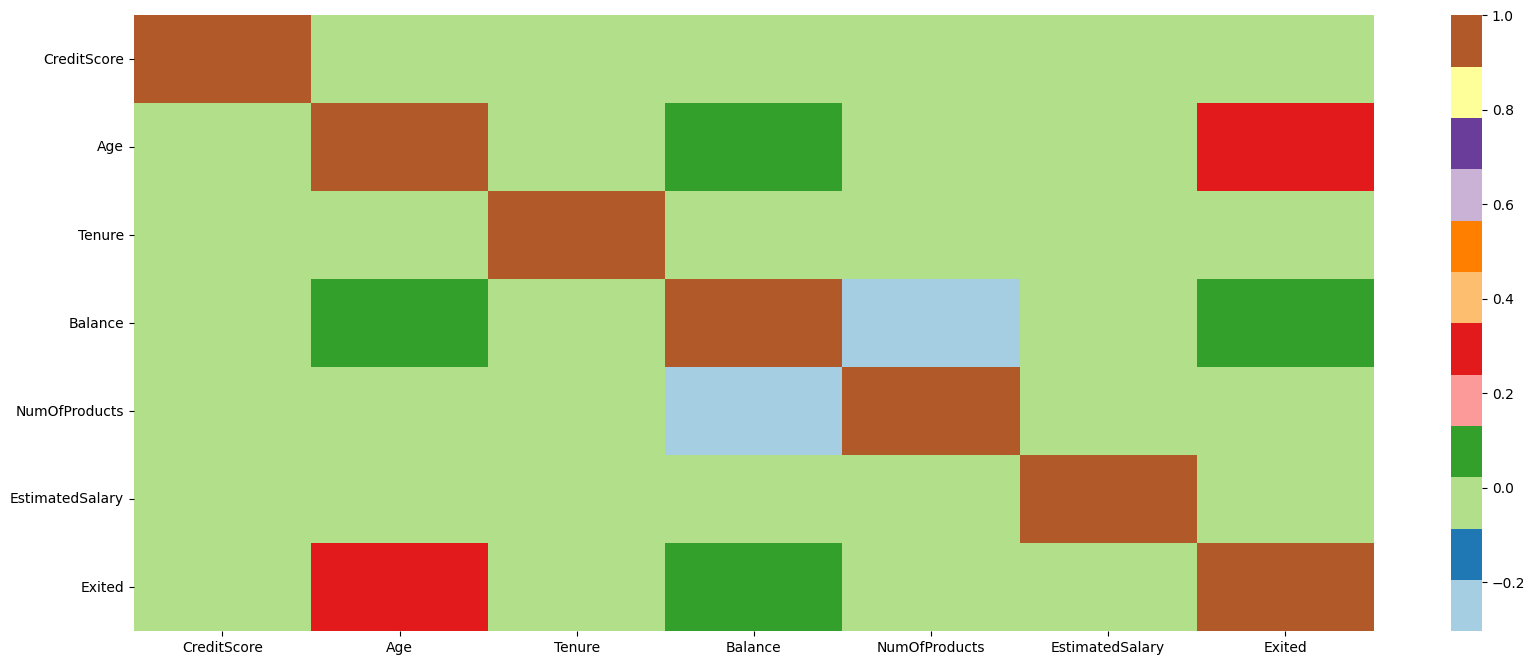

In [53]:
plt.figure(figsize=(20,8))
sns.heatmap(df.corr(), cmap='Paired')

In [54]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
0,619,42,2,0.00,1,101348.88,1
1,608,41,1,83807.86,1,112542.58,0
2,502,42,8,159660.80,3,113931.57,1
3,699,39,1,0.00,2,93826.63,0
4,850,43,2,125510.82,1,79084.10,0


<Axes: xlabel='Age'>

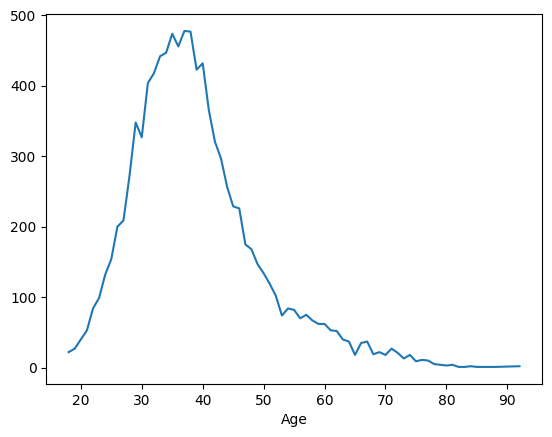

In [55]:
df['Age'].value_counts().sort_index(ascending=True).plot()

In [56]:
df1=df.loc[df['Exited']==1]

<Axes: xlabel='Age'>

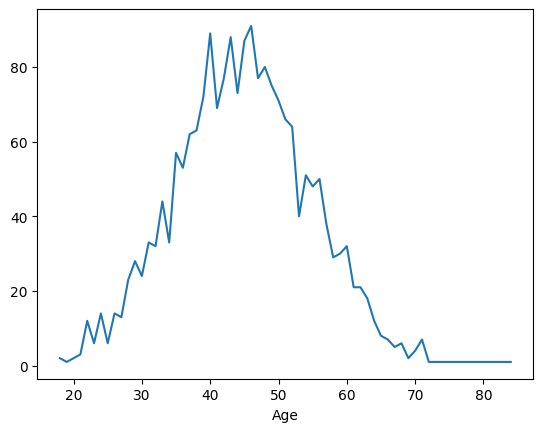

In [57]:
df1['Age'].value_counts().sort_index(ascending=True).plot()

/tmp/ipykernel_17620/1929116962.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Age[(df["Exited"]==0)],
/tmp/ipykernel_17620/1929116962.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Age[(df["Exited"]==1)],


Text(0.5, 1.0, 'Age by churn')

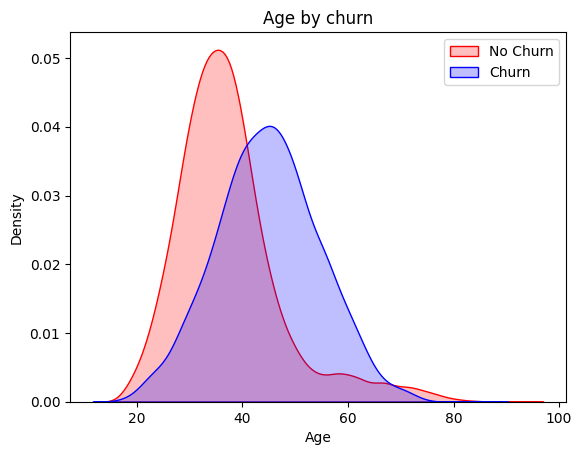

In [60]:
Tot = sns.kdeplot(df.Age[(df["Exited"]==0)],
                  color="Red", shade=True)
Tot = sns.kdeplot(df.Age[(df["Exited"]==1)],
                  color="Blue", shade=True)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Age')
Tot.set_title('Age by churn')

/tmp/ipykernel_17620/1615441249.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Tenure[(df["Exited"]==0)],
/tmp/ipykernel_17620/1615441249.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Tenure[(df["Exited"]==1)],


Text(0.5, 1.0, 'Tenure by churn')

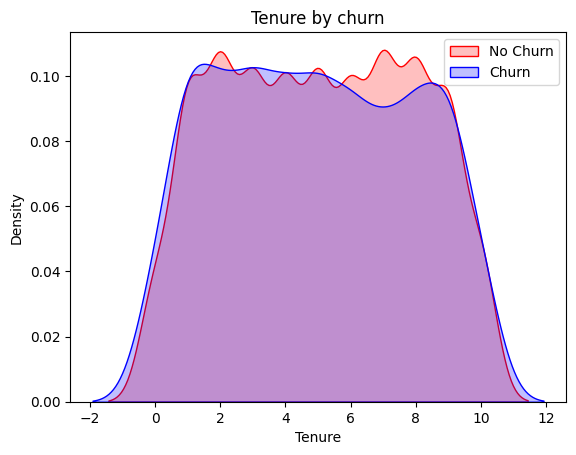

In [61]:
Tot = sns.kdeplot(df.Tenure[(df["Exited"]==0)],
                  color="Red", shade=True)
Tot = sns.kdeplot(df.Tenure[(df["Exited"]==1)],
                  color="Blue", shade=True)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Tenure')
Tot.set_title('Tenure by churn')

/tmp/ipykernel_17620/702535403.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Balance[(df["Exited"]==0)],
/tmp/ipykernel_17620/702535403.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df.Balance[(df["Exited"]==1)],


Text(0.5, 1.0, 'Balance by churn')

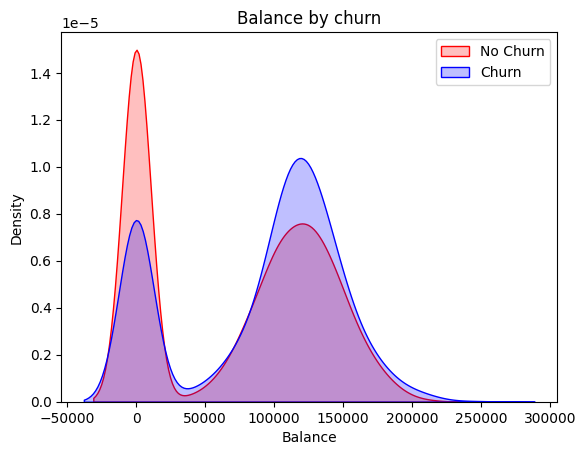

In [64]:
Tot = sns.kdeplot(df.Balance[(df["Exited"]==0)],
                  color="Red", shade=True)
Tot = sns.kdeplot(df.Balance[(df["Exited"]==1)],
                  color="Blue", shade=True)
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Balance')
Tot.set_title('Balance by churn')